# Biomarker Internal Validation
Repeated Stratified K-Fold cross-validation across three gene sets and three classifiers.
Generates ROC curves, Precision-Recall curves, AUC boxplots, and a full performance heatmap.

## 1 · Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import get_scorer
import gc
import gc
import os

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, make_scorer
)

os.makedirs('output', exist_ok=True)

# ── Global plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e8e8e8',
    'grid.linewidth':    0.7,
    'axes.axisbelow':    True,
})

# ── Colour palette (per gene-set) ──────────────────────────────────────────────
PALETTE = {
    'Total':  '#4F86E8',   # vivid blue
    'DEGs':   '#2EC4A5',   # teal
    'Candidate_biomarkers': '#F7775E',   # coral
}
LABELS = {
    'Total':  'Full transcriptome',
    'DEGs':   'DEGs',
    'Candidate_biomarkers': 'Candidate biomarkers',
}

print('Imports OK')

c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 2 · Load data

In [3]:
final_biomarker_df = pd.read_csv('output/extracted_biomarkers.csv')

deg = pd.read_csv(r"output/phase1_degs.csv")
deg_filtered_df = deg[deg['Include_In_Network'] == True]

total_gene_df = pd.read_table(
    r"D:\Dissertation\GDC TCGA Kidney Clear Cell Carcinoma (KIRC)\TCGA-KIRC.star_counts_raw.tsv",
    index_col=0
)
# total_gene_df = pd.read_csv(
#     r"data/expression_matrix.csv",
#     index_col=0
# )

metadata = pd.read_csv(r"data/metadata.csv")

print(f"Total genes : {total_gene_df.shape[0]:,}")
print(f"DEGs        : {deg_filtered_df.shape[0]:,}")
print(f"Biomarker genes: {final_biomarker_df.shape[0]:,}")
print(f"Samples     : {total_gene_df.shape[1]:,}")

Total genes : 60,660
DEGs        : 7,393
Biomarker genes: 170
Samples     : 610


## 3 · Cross-validation

In [ ]:
# ── Gene sets & models ─────────────────────────────────────────────────────────
gene_sets = {
    'Total':  total_gene_df.index.tolist(),
    'DEGs':   deg_filtered_df['Gene'].tolist(),
    'Candidate_biomarkers': final_biomarker_df['Gene'].tolist(),
}

models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'SVM':          SVC(probability=True, kernel='linear', random_state=42),
    'XGBoost':      XGBClassifier(n_estimators=100, use_label_encoder=False,
                                  eval_metric='logloss', random_state=42),
}

# ── CV strategy & scoring ──────────────────────────────────────────────────────
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring = {
    'acc':  'accuracy',
    'prec': 'precision',
    'rec':  'recall',
    'f1':   'f1',
    'auc':  'roc_auc',
    'mcc':  make_scorer(matthews_corrcoef),
}
N_SPLITS = 50  # 5 folds × 10 repeats

# ── Prepare label vector (float32 saves RAM) ───────────────────────────────────
X_total = total_gene_df.T.astype(np.float32)
y = (metadata['Status'] == 'Tumor').astype(int).tolist()

# ── Run ────────────────────────────────────────────────────────────────────────
results_raw   = []
curve_storage = {}   # (set_name, model_name) → (y_true, y_prob)

for set_name, genes in gene_sets.items():
    print(f"\n▶ Gene set: {set_name} ({len(genes):,} genes)")
    X_subset = X_total[genes].values

    for model_name, model_obj in models.items():
        print(f"   · {model_name} ...", end=' ', flush=True)

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    model_obj),
        ])

        # 50-iteration cross-validation
        cv_scores = cross_validate(
            pipeline, X_subset, y,
            cv=cv_strategy,
            scoring=scoring,
            n_jobs=1,
        )
        gc.collect()

        # Store per-fold results
        for i in range(N_SPLITS):
            # print(f"      Fold {i+1}/{N_SPLITS}")
            results_raw.append({
                'Gene_Set':  set_name,
                'Model':     model_name,
                'Accuracy':  cv_scores['test_acc'][i],
                'Precision': cv_scores['test_prec'][i],
                'Recall':    cv_scores['test_rec'][i],
                'F1':        cv_scores['test_f1'][i],
                'AUC':       cv_scores['test_auc'][i],
                'MCC':       cv_scores['test_mcc'][i],
            })
            # print("")

        # Aggregated probabilities for curve plots (single 5-fold pass)
        y_probs = cross_val_predict(
            pipeline, X_subset, y,
            cv=5, method='predict_proba'
        )[:, 1]
        curve_storage[(set_name, model_name)] = (y, y_probs)

        print('done')

results_df = pd.DataFrame(results_raw)
print("\n✓ Cross-validation complete.")


▶ Gene set: Total (60,660 genes)
   · RandomForest ... done
   · SVM ... done
   · XGBoost ... 

c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:24:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:25:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:25:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:25:52] WARNING: C:\actions-runner\_w

done

▶ Gene set: DEGs (7,393 genes)
   · RandomForest ... done
   · SVM ... done
   · XGBoost ... 

c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:48:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:48:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:48:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:48:14] WARNING: C:\actions-runner\_w

done

▶ Gene set: Candidate_biomarkers (170 genes)
   · RandomForest ... done
   · SVM ... done
   · XGBoost ... 

c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:51:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:51:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:51:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:51:26] WARNING: C:\actions-runner\_w

done

✓ Cross-validation complete.


c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:51:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91900\.virtualenvs\GENOME_TOOLKIT-0CQxZHXK\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:51:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4 · Build summary table (mean ± variance)

In [5]:
METRICS = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'MCC']

mean_df = results_df.groupby(['Gene_Set', 'Model'])[METRICS].mean()
var_df  = results_df.groupby(['Gene_Set', 'Model'])[METRICS].var()

# Format as  0.99321 ± 0.00005
formatted = mean_df.copy().astype(str)
for m in METRICS:
    formatted[m] = mean_df[m].map(lambda v: f'{v:.5f}') + ' ± ' + var_df[m].map(lambda v: f'{v:.5f}')

formatted = formatted.reset_index().sort_values('Model')
formatted.to_csv('output/final_performance_summary_with_variance.csv', index=False)

results_df.to_csv('output/full_performance.csv', index=False)

print(formatted.to_string(index=False))

            Gene_Set        Model          Accuracy         Precision            Recall                F1               AUC               MCC
Candidate_biomarkers RandomForest 0.98967 ± 0.00009 0.99035 ± 0.00011 0.99814 ± 0.00001 0.99419 ± 0.00003 0.99430 ± 0.00015 0.94941 ± 0.00225
                DEGs RandomForest 0.99180 ± 0.00006 0.99268 ± 0.00007 0.99814 ± 0.00001 0.99538 ± 0.00002 0.99453 ± 0.00016 0.96043 ± 0.00136
               Total RandomForest 0.99180 ± 0.00005 0.99268 ± 0.00007 0.99814 ± 0.00001 0.99538 ± 0.00002 0.99199 ± 0.00030 0.96038 ± 0.00125
Candidate_biomarkers          SVM 0.98770 ± 0.00006 0.99411 ± 0.00005 0.99201 ± 0.00006 0.99302 ± 0.00002 0.98974 ± 0.00031 0.94247 ± 0.00134
                DEGs          SVM 0.99098 ± 0.00005 0.99559 ± 0.00004 0.99424 ± 0.00005 0.99489 ± 0.00002 0.98815 ± 0.00038 0.95763 ± 0.00105
               Total          SVM 0.98951 ± 0.00005 0.99523 ± 0.00006 0.99294 ± 0.00006 0.99405 ± 0.00002 0.98953 ± 0.00032 0.95113 ± 0.00113
Candid

## 5 · Plot A — ROC & Precision-Recall curves (3 models × 2 plot types)

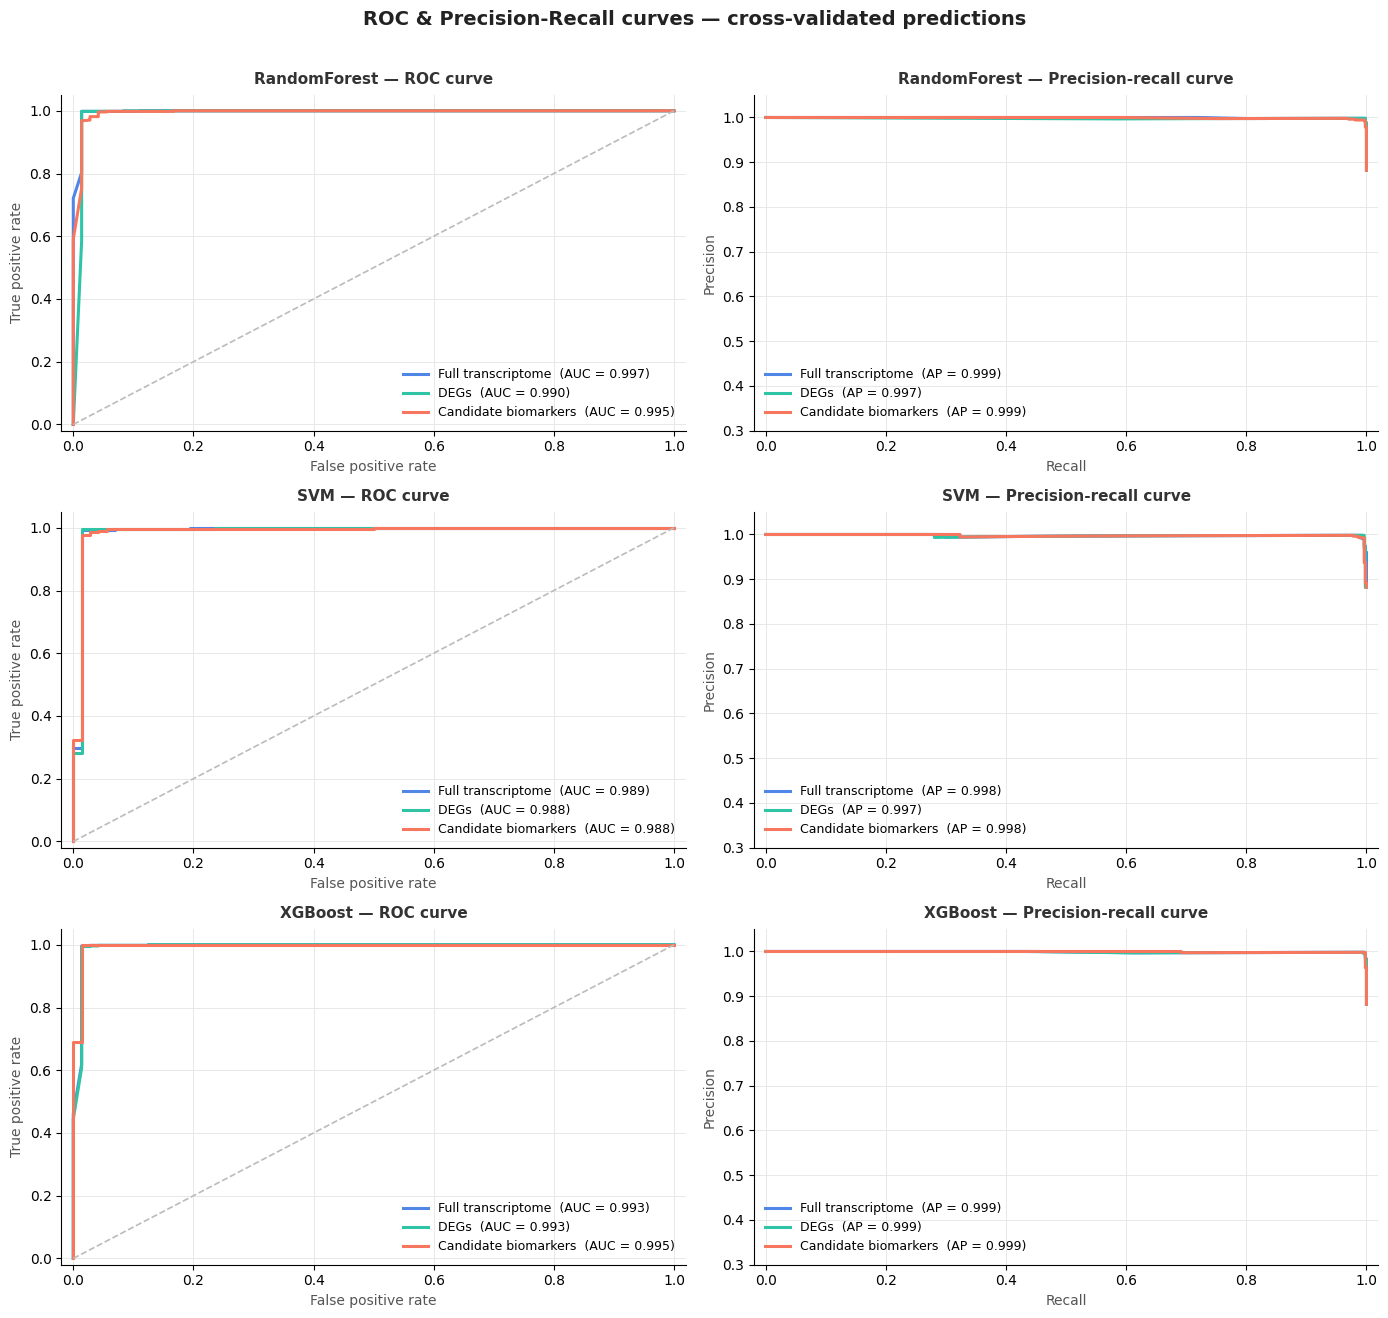

Saved → output/plot_A_roc_pr_curves.*


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle(
    'ROC & Precision-Recall curves — cross-validated predictions',
    fontsize=14, fontweight='bold', color='#222', y=1.01
)

for row, model_name in enumerate(models.keys()):
    ax_roc = axes[row, 0]
    ax_pr  = axes[row, 1]

    for set_name in gene_sets:
        y_true, y_prob = curve_storage[(set_name, model_name)]
        color = PALETTE[set_name]
        label = LABELS[set_name]

        # ROC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc     = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, color=color, linewidth=2.2,
                    label=f'{label}  (AUC = {roc_auc:.3f})')

        # PR
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ap            = average_precision_score(y_true, y_prob)
        ax_pr.plot(rec, prec, color=color, linewidth=2.2,
                   label=f'{label}  (AP = {ap:.3f})')

    # ── ROC decoration ────────────────────────────────────────────────────────
    ax_roc.plot([0, 1], [0, 1], '--', color='#bbbbbb', linewidth=1.2)
    ax_roc.set_xlim(-0.02, 1.02)
    ax_roc.set_ylim(-0.02, 1.05)
    ax_roc.set_xlabel('False positive rate', fontsize=10, color='#555')
    ax_roc.set_ylabel('True positive rate',  fontsize=10, color='#555')
    ax_roc.set_title(f'{model_name} — ROC curve', fontsize=11,
                     fontweight='bold', color='#333', pad=8)
    ax_roc.legend(fontsize=9, frameon=False)

    # ── PR decoration ─────────────────────────────────────────────────────────
    ax_pr.set_xlim(-0.02, 1.02)
    ax_pr.set_ylim(0.30, 1.05)
    ax_pr.set_xlabel('Recall',    fontsize=10, color='#555')
    ax_pr.set_ylabel('Precision', fontsize=10, color='#555')
    ax_pr.set_title(f'{model_name} — Precision-recall curve', fontsize=11,
                    fontweight='bold', color='#333', pad=8)
    ax_pr.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('output/plot_A_roc_pr_curves.pdf', bbox_inches='tight', dpi=150)
plt.savefig('output/plot_A_roc_pr_curves.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved → output/plot_A_roc_pr_curves.*')

## 6 · Plot B — AUC boxplots (stability across 50 iterations)

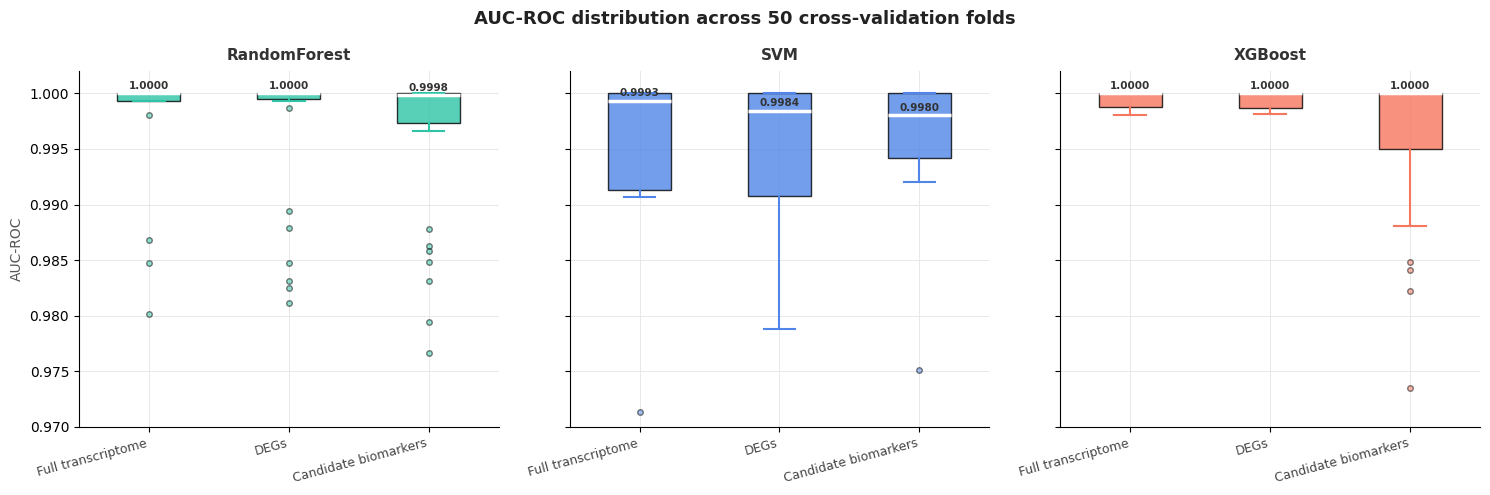

Saved → output/plot_B_auc_boxplots.*


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle(
    'AUC-ROC distribution across 50 cross-validation folds',
    fontsize=13, fontweight='bold', color='#222'
)

MODEL_COLORS = {'SVM': '#4F86E8', 'RandomForest': '#2EC4A5', 'XGBoost': '#F7775E'}

for ax, model_name in zip(axes, models.keys()):
    subset = results_df[results_df['Model'] == model_name]

    bp = ax.boxplot(
        [subset[subset['Gene_Set'] == gs]['AUC'].values for gs in gene_sets],
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color=MODEL_COLORS[model_name], linewidth=1.5),
        capprops=dict(color=MODEL_COLORS[model_name], linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor=MODEL_COLORS[model_name],
                        markersize=4, alpha=0.5, linestyle='none'),
    )

    # Colour each box
    base_color = MODEL_COLORS[model_name]
    for patch in bp['boxes']:
        patch.set_facecolor(base_color)
        patch.set_alpha(0.80)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(
        [LABELS[gs] for gs in gene_sets],
        fontsize=9, rotation=15, ha='right', color='#444'
    )
    ax.set_title(model_name, fontsize=11, fontweight='bold', color='#333', pad=8)
    ax.set_ylabel('AUC-ROC' if ax == axes[0] else '', fontsize=10, color='#555')
    ax.set_ylim(0.97, 1.002)

    # Annotate median
    for i, gs in enumerate(gene_sets, start=1):
        med = subset[subset['Gene_Set'] == gs]['AUC'].median()
        ax.text(i, med + 0.0002, f'{med:.4f}',
                ha='center', va='bottom', fontsize=7.5, color='#333', fontweight='bold')

plt.tight_layout()
plt.savefig('output/plot_B_auc_boxplots.pdf', bbox_inches='tight', dpi=150)
plt.savefig('output/plot_B_auc_boxplots.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved → output/plot_B_auc_boxplots.*')

## 7 · Plot C — Multi-metric grouped bar chart (like the reference figure)

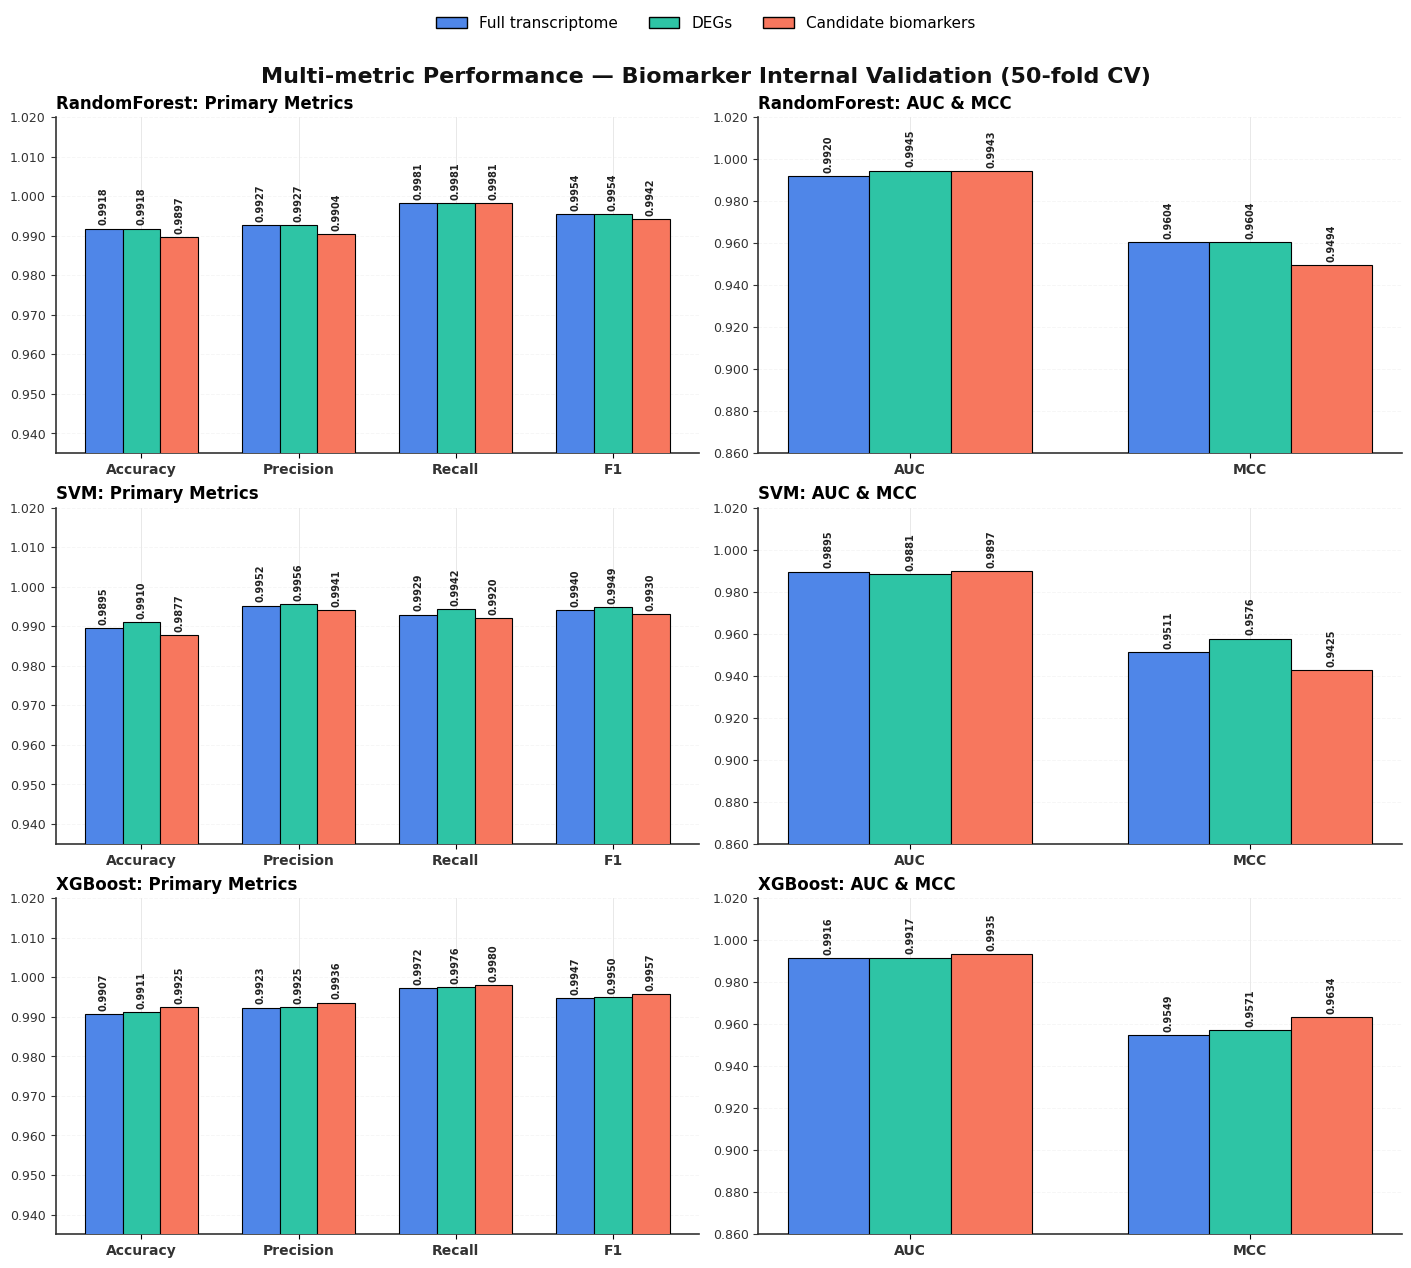

In [8]:
MAIN_METRICS  = ['Accuracy', 'Precision', 'Recall', 'F1']

FOCUS_METRICS = ['AUC', 'MCC']



mean_vals = results_df.groupby(['Gene_Set', 'Model'])[METRICS].mean()
# --- Updated Styling Constants (Optional but recommended for prominence) ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.2

def grouped_bar_ax(ax, model, metric_list, y_min, y_max):
    """Draw one grouped bar subplot with enhanced visual prominence."""
    n_groups = len(metric_list)
    n_bars   = len(gene_sets)
    bar_w    = 0.24  # Slightly wider bars
    offsets  = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_w
    x        = np.arange(n_groups)

    # Add a light horizontal grid for readability
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

    for gs, offset in zip(gene_sets, offsets):
        vals = [mean_vals.loc[(gs, model), m] for m in metric_list]
        bars = ax.bar(
            x + offset, vals,
            width=bar_w,
            color=PALETTE[gs],
            label=LABELS[gs],
            edgecolor='black', # Darker edge for prominence
            linewidth=0.8,
            zorder=3,
        )
        
        # Enhanced annotations
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (y_max - y_min) * 0.01,
                f'{val:.4f}',
                ha='center', va='bottom',
                # Bold and slightly larger font for metrics
                fontsize=7, fontweight='bold', color='#222', rotation=90,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_list, fontsize=10, fontweight='bold', color='#333')
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
    ax.tick_params(axis='y', labelsize=9, colors='#333')
    
    # Thicker spines for prominence
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#333')
    ax.spines['left'].set_linewidth(1.2)

# Use layout='constrained' for a tighter fit without manual hspace/wspace fighting
fig, axes = plt.subplots(3, 2, figsize=(14, 12), layout='constrained')

for row, model_name in enumerate(models.keys()):
    # Slightly tighter y-limits can make small differences look more prominent
    grouped_bar_ax(axes[row, 0], model_name, MAIN_METRICS,  y_min=0.935, y_max=1.02)
    grouped_bar_ax(axes[row, 1], model_name, FOCUS_METRICS, y_min=0.86, y_max=1.02)

    # Left-aligned titles often look cleaner in tight layouts
    axes[row, 0].set_title(f'{model_name}: Primary Metrics', loc='left', fontsize=12, fontweight='bold')
    axes[row, 1].set_title(f'{model_name}: AUC & MCC', loc='left', fontsize=12, fontweight='bold')

# Shared legend
legend_handles = [mpatches.Patch(color=PALETTE[gs], label=LABELS[gs], ec='black') for gs in gene_sets]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=len(gene_sets),
    fontsize=11,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05), # Positioned above the suptitle area
)

fig.suptitle(
    'Multi-metric Performance — Biomarker Internal Validation (50-fold CV)',
    fontsize=16, fontweight='bold', color='#111'
)

# Using bbox_inches='tight' ensures the legend and suptitle aren't cut off
plt.savefig('output/plot_C_grouped_bar.pdf', bbox_inches='tight', dpi=150)
plt.savefig('output/plot_C_grouped_bar.png', bbox_inches='tight', dpi=600)
plt.show()

## 8 · Plot D — Performance heatmap (mean AUC per model × gene-set)

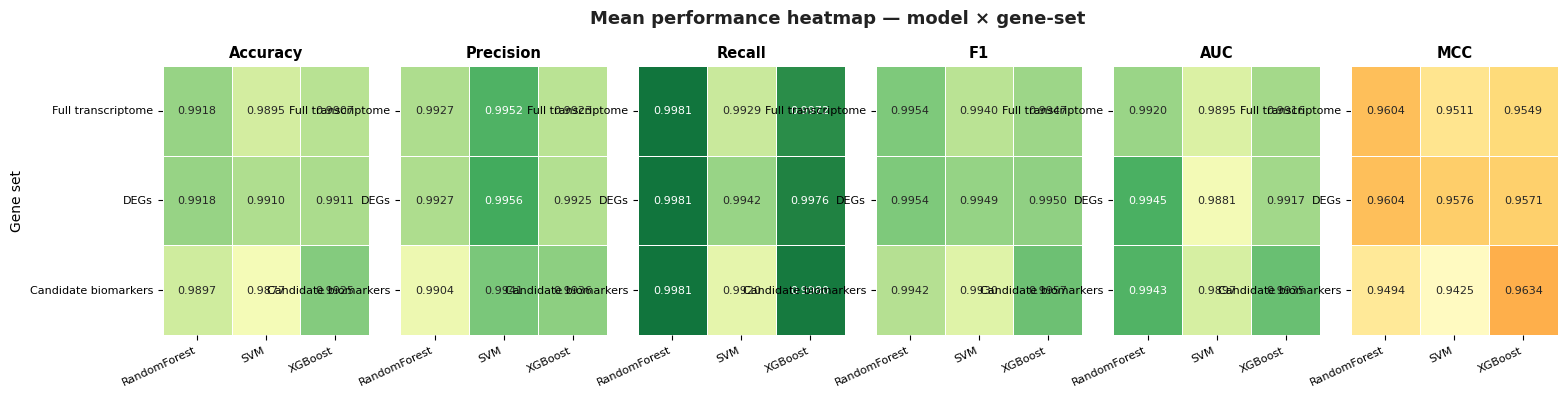

Saved → output/plot_D_heatmap.*


In [9]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 3.5),
                         gridspec_kw={'wspace': 0.15})
fig.suptitle(
    'Mean performance heatmap — model × gene-set',
    fontsize=13, fontweight='bold', color='#222', y=1.04
)

for ax, metric in zip(axes, METRICS):
    pivot = mean_vals[metric].unstack(level='Model')   # rows = Gene_Set, cols = Model
    # Reorder rows/cols for readability
    pivot = pivot.loc[list(gene_sets.keys()), list(models.keys())]

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt='.4f',
        annot_kws={'fontsize': 8},
        cmap='YlGn' if metric != 'MCC' else 'YlOrRd',
        vmin=pivot.values.min() - 0.002,
        vmax=1.0,
        linewidths=0.5,
        linecolor='white',
        cbar=False,
        square=False,
    )
    ax.set_title(metric, fontsize=10.5, fontweight='bold', pad=6)
    ax.set_xlabel('')
    ax.set_ylabel('Gene set' if ax == axes[0] else '')
    ax.set_yticklabels(
        [LABELS[gs] for gs in pivot.index],
        fontsize=8, rotation=0
    )
    ax.set_xticklabels(pivot.columns, fontsize=8, rotation=25, ha='right')

plt.savefig('output/plot_D_heatmap.pdf', bbox_inches='tight', dpi=150)
plt.savefig('output/plot_D_heatmap.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved → output/plot_D_heatmap.*')

## 9 · Summary
All outputs are saved under `output/`:

| File | Contents |
|------|----------|
| `full_performance.csv` | Raw per-fold metrics (50 rows per model × gene-set) |
| `final_performance_summary_with_variance.csv` | Mean ± variance for every metric |
| `plot_A_roc_pr_curves.*` | ROC & PR curves for all 3 models |
| `plot_B_auc_boxplots.*` | AUC stability boxplots (50 folds) |
| `plot_C_grouped_bar.*` | Multi-metric grouped bar chart (6 subplots) |
| `plot_D_heatmap.*` | Performance heatmap per metric |